In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv("dataset.csv")

print(df.head())
print(df.info())

    AGE     BP  CHOLESTROL gender   bmi family_history smoking_status  \
0  56.0   95.0       174.0      F  27.2             no     non-smoker   
1  69.0   94.0       120.0      F  27.1            NaN         smoker   
2  46.0  116.0       200.0      M  23.8             no         smoker   
3  32.0  121.0       212.0      M  30.3             no     non-smoker   
4  60.0  110.0       150.0      M  28.6             no         smoker   

  alcohol_consumption physical_activity  stress_level  sleep_hours diabetes  \
0                  no              high           8.0          7.7      yes   
1                 yes              high           1.5          9.2       no   
2                  no            medium           9.0          3.3       no   
3                  no              high           1.0          3.8       no   
4                  no            medium          10.0          4.6       no   

  hypertension  
0           no  
1           no  
2           no  
3           no  
4

In [3]:
# Fill numeric columns with median
df.fillna(df.median(numeric_only=True), inplace=True)

,AGE,BP,CHOLESTROL,gender,bmi,family_history,smoking_status,alcohol_consumption,physical_activity,stress_level,sleep_hours,diabetes,hypertension
0,56.0,95.0,174.0,F,27.20,no,non-smoker,no,high,8.0,7.70,yes,no
1,69.0,94.0,120.0,F,27.10,NaN,smoker,yes,high,1.5,9.20,no,no
2,46.0,116.0,200.0,M,23.80,no,smoker,no,medium,9.0,3.30,no,no
3,32.0,121.0,212.0,M,30.30,no,non-smoker,no,high,1.0,3.80,no,no
4,60.0,110.0,150.0,M,28.60,no,smoker,no,medium,10.0,4.60,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,60.0,122.0,220.0,M,34.50,no,non-smoker,NaN,low,3.0,2.07,no,yes
199996,60.0,129.0,190.0,M,27.00,no,non-smoker,yes,medium,9.0,4.20,yes,no
199997,40.0,93.0,175.0,F,25.70,yes,smoker,no,low,3.0,5.70,no,no
199998,71.0,264.0,219.0,F,7.41,no,non-smoker,no,low,9.0,5.60,no,no


In [5]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter rows (apply on numeric columns only)
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [12]:
df["heart_risk"] = (
    (df["BP"] > 140) |
    (df["CHOLESTROL"] > 240) |
    (df["bmi"] > 30) |
    (df["smoking_status"] == 1)
).astype(int)

X = df.drop("heart_risk", axis=1)
y = df["heart_risk"]
X = pd.get_dummies(X, drop_first=True)

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

results = []

In [29]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, pre, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.830546   0.779860  0.690485  0.732456
1                  KNN  0.875952   0.910674  0.699336  0.791134
2                  SVM  0.968531   0.958574  0.947262  0.952884


In [30]:
best_model = results_df.sort_values(by="Accuracy", ascending=False)
print(best_model)

                 Model  Accuracy  Precision    Recall  F1 Score
2                  SVM  0.968531   0.958574  0.947262  0.952884
1                  KNN  0.875952   0.910674  0.699336  0.791134
0  Logistic Regression  0.830546   0.779860  0.690485  0.732456


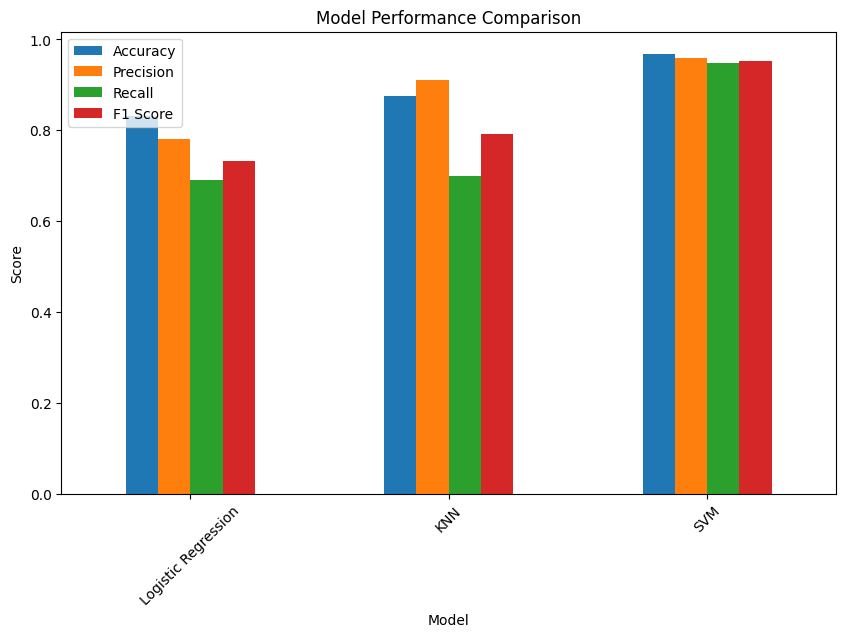

In [31]:
results_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


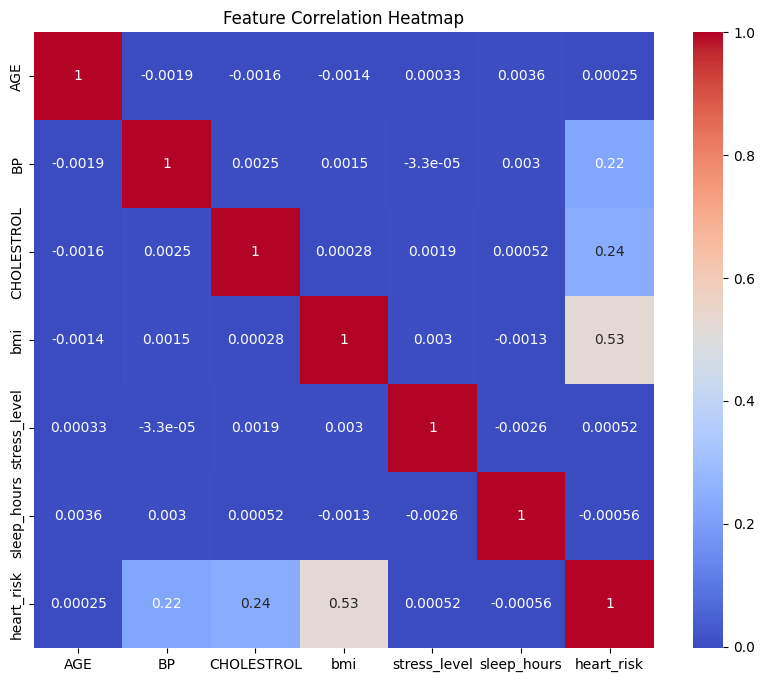

In [32]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

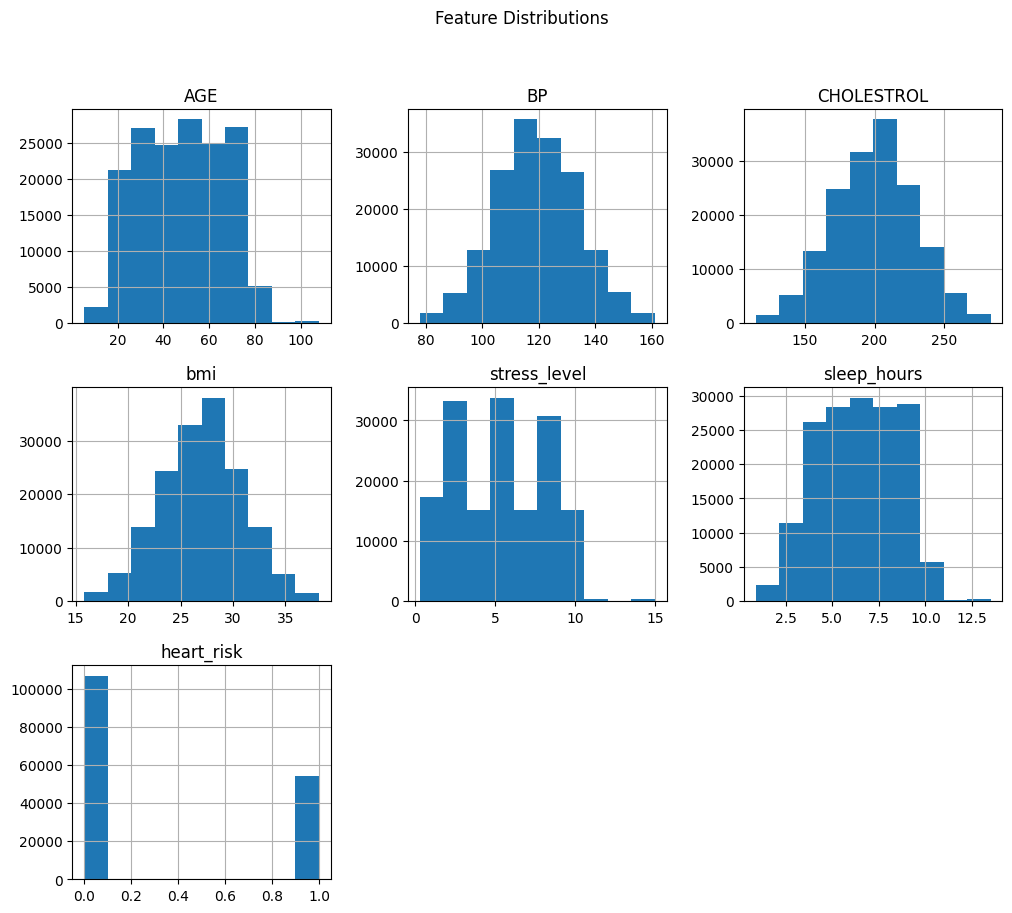

In [33]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

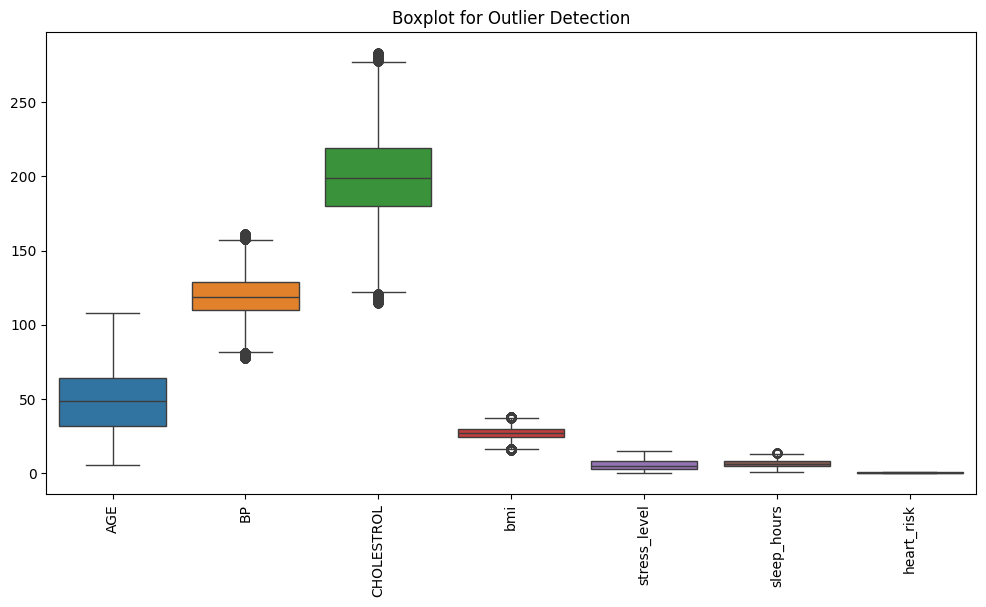

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

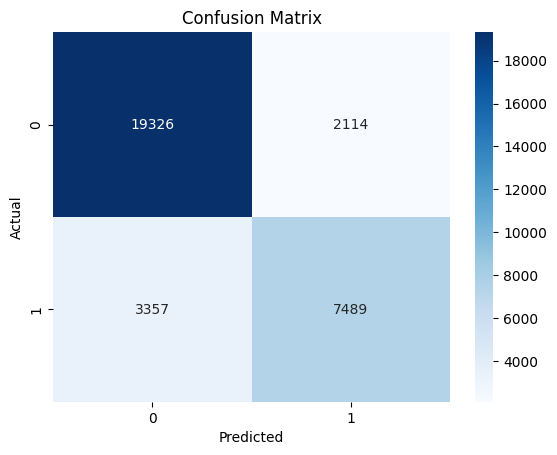

In [35]:
best = LogisticRegression()  # replace with actual best after checking
best.fit(X_train, y_train)
y_pred = best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
def get_user_input():
    data = {
        "AGE": int(input("Enter Age: ")),
        "BP": float(input("Enter Blood Pressure: ")),
        "CHOLESTROL": float(input("Enter Cholesterol: ")),
        "gender": input("Enter Gender (M/F): "),
        "bmi": float(input("Enter BMI: ")),
        "family_history": input("Family History (Yes/No): "),
        "smoking_status": input("Smoking (Yes/No): "),
        "alcohol_consumption": input("Alcohol (Low/Moderate/High): "),
        "physical_activity": input("Physical Activity (Low/Moderate/High): "),
        "stress_level": input("Stress Level (Low/Moderate/High): "),
        "sleep_hours": float(input("Sleep Hours: ")),
        "diabetes": int(input("Diabetes (0/1): "))
    }
    return data

In [39]:
X = pd.get_dummies(X, drop_first=True)
feature_columns = X.columns   # ✅ ADD THIS LINE

In [40]:
def predict_heart_disease(input_dict):
    
    input_df = pd.DataFrame([input_dict])
    
    # Encode
    input_df = pd.get_dummies(input_df)
    
    # Match training columns
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)
    
    # Scale
    input_scaled = scaler.transform(input_df)
    
    # Predict
    prediction = best.predict(input_scaled)
    
    return "High Risk of Heart Disease" if prediction[0] == 1 else "Low Risk"

In [41]:
user_data = get_user_input()
result = predict_heart_disease(user_data)

print("\nPrediction Result:", result)


Prediction Result: Low Risk
